# Building a coupler
## Visions

1. A `Master` class to manage the clock, and call each component.
2. A `coupler` component that is responsible for computing fluxes or exchange fluxes.

## Thoughts

The coupler is the component that holds the shared flux information. The coupler does not have to compute fluxes. It should have default functions that can compute fluxes, and the ability to allow other components of the model to determine the fluxes.

## How things work

1. The `Master` is constructed.
2. Create `Component` (atm, ocn, lnd models).
3. Register how many components there are and what they are in `Master`.
4. Assign the order to run each component, and perhaps some in-between callback functions.
5. Print out the plan.

# Model

The model is a slab-atmosphere-model (SAM) and a slab-ocean-model (SOM). They only have one grid point each.


## Atmosphere

$ m_a c_{pa} \partial_t T_a = - \left( LW_{TOA} + SW_{TOA} - SW_{sfc} - LHF \right) $

## Ocean

$ d c_{po} \rho_{o} \partial_t T_o = - \left( SW_{sfc} + LHF \right) $

## Flux

- Longwave radiation flux at top-of-atmoshpere: $ LW_{TOA} = \sigma T_a^4 $
- Shortwave radiation flux at top-of-atmosphere: $ SW_{TOA}\left(t\right) = \min \left[ 0, - S_0 \sin \left( 2 \pi t / \mathrm{day} \right) \right] $
- Shortwave radiation flux at surface: $ SW_{sfc} = 0.8 \times SW_{TOA} $
- Latent heat flux: $ LHF = \rho_a C_H U \left( T_o - T_a \right) $

## Constants

- Solar constant: $S_0 = 1367 \mathrm{W} / \mathrm{m}^2$
- Mass of air column: $m_a = 1 \times 10^4 \mathrm{kg} / \mathrm{m}^2$
- Stephen-Boltzmann constant: $\sigma = 5.67 \times 10^{-8} \mathrm{W} / \mathrm{m}^2 / \mathrm{K}^4$
- Air density: $\rho_a = 1.2 \mathrm{kg}/\mathrm{m}^3$
- Seawater density: $\rho_o = 1025 \mathrm{kg}/\mathrm{m}^3$
- Specific heat of air: $ c_{pa} = 1004 \mathrm{J} / \mathrm{K} / \mathrm{kg} $
- Specific heat of seawater: $ c_{po} = 3985 \mathrm{J} / \mathrm{K} / \mathrm{kg} $
- Wind speed: $ U = 5 \mathrm{m} / \mathrm{s}$
- Coefficient of heat transfer: $ C_H = 1 \times 10^{-3}$

In [1]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path in sys.path:
    print("Path exist")
else:
    print("Add Path...")
    sys.path.append(module_path)

Add Path...


In [2]:
import numpy as np

from jax_esm.Master import Master
from jax_esm.components.base import ComponentConfig

from jax_esm.components.SlabOceanModel import SlabOceanModel
from jax_esm.components.SlabAtmosphereModel import SlabAtmosphereModel
from jax_esm.components.FluxModel import FluxModel


In [3]:

# Master Config
config_master = dict(
    time_step = 3600.0, # sec
)

# Ocean model
config_atm = ComponentConfig(
    name = "atm",
    timestep = 600.0, # seconds
    grid = None,
    params = None,
)
model_atm = SlabAtmosphereModel(config_atm)

# Ocean model
config_ocn = ComponentConfig(
    name = "ocn",
    timestep = 600.0, # seconds
    grid = None,
    params = None,
)
model_ocn = SlabOceanModel(config_ocn)

# Flux model
config_flx = ComponentConfig(
    name = "flx",
    timestep = 600.0, # seconds
    grid = None,
    params = None,
)
model_flx = FluxModel(config_flx)

execution_order = ["flx", "atm", "ocn"]

In [4]:
master = Master(
    config = config_master,
    components = dict(
        ocn = model_ocn,
        atm = model_atm,
        flx = model_flx,
    ), 
    execution_order = execution_order,
)

In [5]:
master.checkPlan()
master.printPlan()


Print execution plan:
[ 1] : flx 
[ 2] : atm 
[ 3] : ocn 


In [6]:
master.init()

model_ocn.state.T = model_ocn.state.T * 0 + 288.15
model_atm.state.T = model_atm.state.T * 0 + 288.15

init_states = {
    name: master.components[name].state.copy()
    for name in ["atm", "ocn"]
}



In [7]:
time_length = 86400.0 * 10
timesteps = int(time_length / master.config["time_step"])

record_names = ["atm.T", "ocn.T", "flx.lhflx", "flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa"]
recorder = {
    name: np.zeros((timesteps,))
    for name in record_names
}

def record(recorder, idx, master, full_varnames):
    for full_varname in full_varnames:
        cmpt, varname = full_varname.split(".")
        recorder[full_varname][idx] = getattr(master.components[cmpt].state, varname)[0]

record(recorder, 0, master, record_names)
for timestep in range(timesteps):
    if timestep % 240 == 0 or timestep == timesteps-1:
        print(f"Timestep: {timestep:d}")
    master.run()
    record(recorder, timestep, master, record_names)

Timestep: 0
Timestep: 239


In [9]:
master.reportComponents()

Latent heat flux =  107.67514
Top-of-atmosphere shortwave rad flux =  0.0
Surface shortwave rad flux =  0.0
Atmoshpere temperature =  271.4105
Ocean temperature =  289.3548


# Diagnostics

Check:
1. Total Energy
2. Timeseries

In [12]:
# Check total energy
import numpy as np

swflx_toa = - 1200.0
total_energy_input = - swflx_toa * time_length

computed_energy_change = np.sum(
    (model_atm.state.T - init_states["atm"].T) * model_atm.column_mass * model_atm.cp 
    + (model_ocn.state.T - init_states["ocn"].T) * model_ocn.ocn_rho * model_ocn.ocn_cp * model_ocn.mld
)

diff = 1.0 - computed_energy_change / total_energy_input

print(f"Expected total energy: {total_energy_input:f}")
print(f"Simulated total energy: {computed_energy_change:f}")
print(f"Difference = {diff*100:f} %")


Expected total energy: 1036800000.000000
Simulated total energy: 77993936.000000
Difference = 92.477432 %


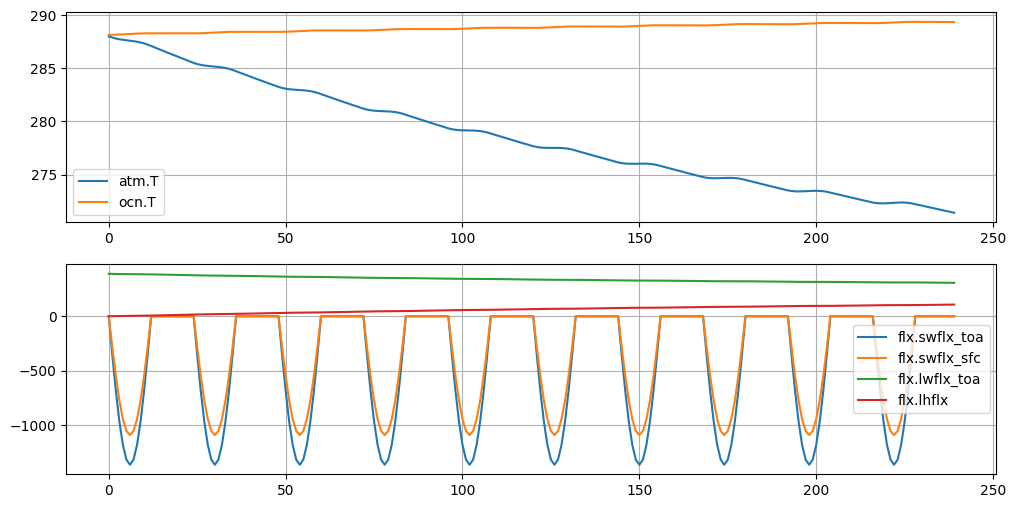

In [13]:
import matplotlib.pyplot as plt


def simple_moving_average(data, window_size):
    weights = np.ones(window_size) / window_size
    sma = np.convolve(data, weights, mode='same')
    return sma

plot_names = [
    ("atm.T", "ocn.T",),
    ("flx.swflx_toa", "flx.swflx_sfc", "flx.lwflx_toa", "flx.lhflx",),
]

N_plot_names = len(plot_names)

fig, ax = plt.subplots(N_plot_names, 1, figsize=(12, 3*N_plot_names))
smooth_window_half_size = 0
smooth_window = smooth_window_half_size * 2 + 1
for i, full_varnames in enumerate(plot_names):
    _ax = ax[i]

    for j, full_varname in enumerate(full_varnames):
        y = recorder[full_varname]
        y_smooth = simple_moving_average(y, smooth_window)
        y_smooth[:smooth_window_half_size] = np.nan
        y_smooth[len(y)-smooth_window_half_size:] = np.nan
        _ax.plot(range(len(y)), y_smooth, label=full_varname)
        
    _ax.legend()
    _ax.grid()
plt.show()